# Homework 5

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import norm

## Exercise 1: Correlations
Let's recreate the plot from the lecture. Assume two neurons that are tuned to a directed stimulus $s\in[0, 2\pi]$. The neurons are Poisson neurons with rates (in Hz)
\begin{align}
r_1(s) &= \exp\left(\sin(s - \frac{\pi}{4})\right) \\
r_2(s) &= \exp\left(\sin\left(s - \frac{\pi}{2}\right)\right)
\end{align}

a) Draw 10,000 stimuli uniformly. For both neurons, draw spike counts for a measurement duration of 25 seconds and save the firing rates. Discretize the range for the stimuli into 20 bins and compute the tuning curves (average firing rate). Plot the tuning curves for both neurons into separate subplots. Additionally, pick one bin and plot all firing rates for that bin as a scatter plot (for each neuron, plot into the same corresponding subplot). (3 points)

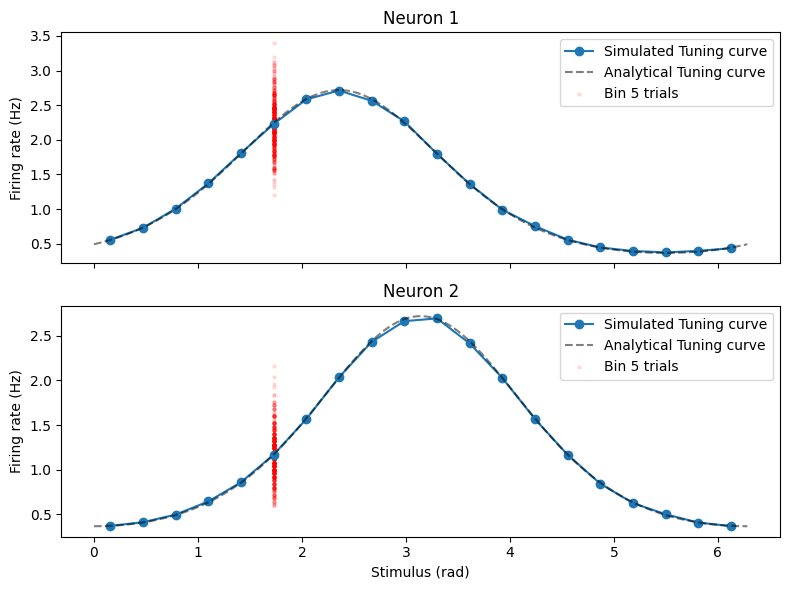

In [2]:
N = 10000
duration = 25.0              
n_bins = 20        

# Draw stimuli
s = np.random.uniform(0, 2*np.pi, size=N)

# Compute Poisson rates
r1 = np.exp(np.sin(s - np.pi/4))
r2 = np.exp(np.sin(s - np.pi/2))

# Draw spike counts and convert to firing rates
counts1 = np.random.poisson(r1 * duration)
counts2 = np.random.poisson(r2 * duration)
fr1 = counts1 / duration
fr2 = counts2 / duration

# Bin into 20 bins and calc tuning curves
bins = np.linspace(0, 2*np.pi, n_bins+1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_idx = np.digitize(s, bins) - 1

tuning1 = np.array([fr1[bin_idx == i].mean() for i in range(n_bins)])
tuning2 = np.array([fr2[bin_idx == i].mean() for i in range(n_bins)])

s_grid = np.linspace(0, 2*np.pi, 1000)
analytical_tuning1 = np.exp(np.sin(s_grid - np.pi/4))
analytical_tuning2 = np.exp(np.sin(s_grid - np.pi/2))


# Pick bin to inspect variability
selected_bin = 5
fr1_sel = fr1[bin_idx == selected_bin]
fr2_sel = fr2[bin_idx == selected_bin]
x_sel = np.full_like(fr1_sel, bin_centers[selected_bin])

# Plot
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# Neuron 1
axes[0].plot(bin_centers, tuning1, '-o', label='Simulated Tuning curve')
axes[0].plot(s_grid, analytical_tuning1, '--', c='k', alpha=0.5, label='Analytical Tuning curve')
axes[0].scatter(x_sel, fr1_sel, alpha=0.1, s=5, color='red', label=f'Bin {selected_bin} trials')
axes[0].set_ylabel('Firing rate (Hz)')
axes[0].set_title('Neuron 1')
axes[0].legend()

# Neuron 2
axes[1].plot(bin_centers, tuning2, '-o', label='Simulated Tuning curve')
axes[1].plot(s_grid, analytical_tuning2, '--', c='k', alpha=0.5, label='Analytical Tuning curve')
axes[1].scatter(x_sel, fr2_sel, alpha=0.1, s=5, color='red', label=f'Bin {selected_bin} trials')
axes[1].set_xlabel('Stimulus (rad)')
axes[1].set_ylabel('Firing rate (Hz)')
axes[1].set_title('Neuron 2')
axes[1].legend()

plt.tight_layout()
plt.show()

b) For this one bin, scatter plot the firing rates. Compute and plot the noise correlation. (1 point)

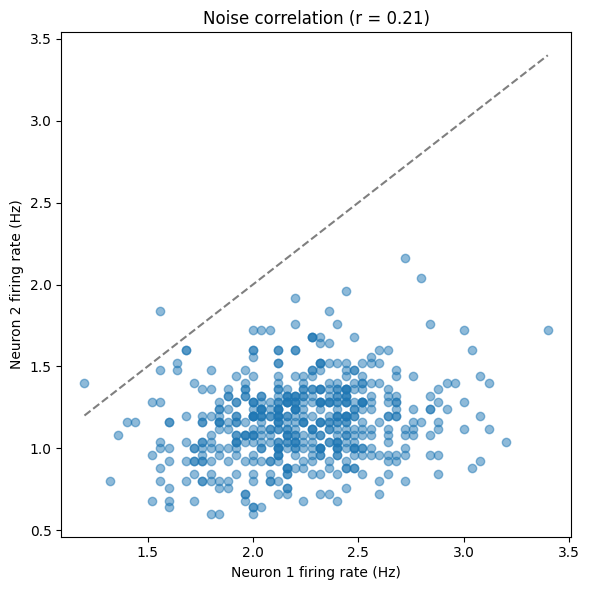

In [3]:
noise_corr = np.corrcoef(fr1_sel, fr2_sel)[0, 1]

plt.figure(figsize=(6, 6))
plt.scatter(fr1_sel, fr2_sel, alpha=0.5)
plt.xlabel('Neuron 1 firing rate (Hz)')
plt.ylabel('Neuron 2 firing rate (Hz)')
plt.title(f'Noise correlation (r = {noise_corr:.2f})')
plt.plot([fr1_sel.min(), fr1_sel.max()],
         [fr1_sel.min(), fr1_sel.max()], 'k--', alpha=0.5)
plt.tight_layout()
plt.show()

c) Scatter plot the simulated tuning curves. Compute and plot the signal correlation. (1 point)

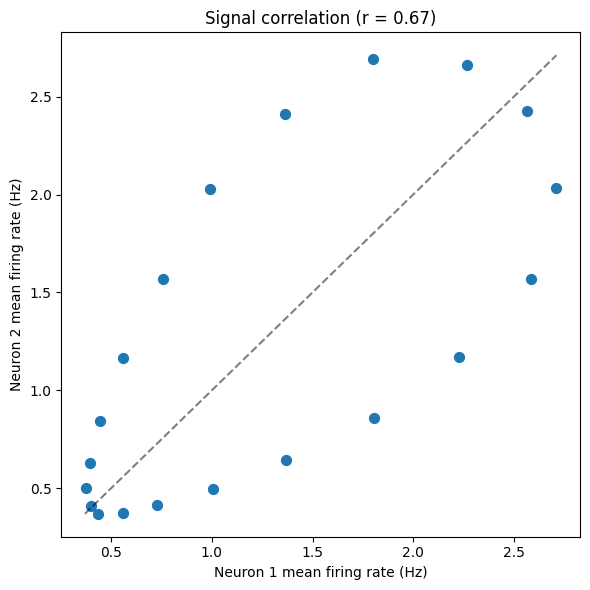

In [4]:
signal_corr = np.corrcoef(tuning1, tuning2)[0, 1]

# Scatter plot of tuning curves
plt.figure(figsize=(6, 6))
plt.scatter(tuning1, tuning2, s=50)
plt.xlabel('Neuron 1 mean firing rate (Hz)')
plt.ylabel('Neuron 2 mean firing rate (Hz)')
plt.title(f'Signal correlation (r = {signal_corr:.2f})')

# Optional unity line for reference
lims = [min(tuning1.min(), tuning2.min()), max(tuning1.max(), tuning2.max())]
plt.plot(lims, lims, 'k--', alpha=0.5)

plt.tight_layout()
plt.show()

d) Confirm the law of total covariance by computing all of its components (2x2 matrices). (1 point)

In [5]:
# Total covariance matrix of firing rates
rates = np.vstack([fr1, fr2])  
total_cov = np.cov(rates, ddof=0)

# Noise covariance (need to use weighting since not all bins have same probability)
noise_cov = sum((np.sum(bin_idx==i)/N) * np.cov(np.vstack([fr1[bin_idx==i], fr2[bin_idx==i]]),ddof=0) for i in range(n_bins))

# Signal covariance (also using weighting)
mu = np.array([fr1.mean(), fr2.mean()])[:,None]
signal_cov = sum((np.sum(bin_idx==i)/N) * np.outer(
    np.array([tuning1[i], tuning2[i]]) - mu.flatten(),
    np.array([tuning1[i], tuning2[i]]) - mu.flatten()) for i in range(n_bins))

# Confirm law of total covariance
reconstructed_total = noise_cov + signal_cov
print("Total covariance:\n", total_cov)
print("Noise covariance:\n", noise_cov)
print("Signal covariance:\n", signal_cov)
print("Noise + Signal:\n", reconstructed_total)
assert np.allclose(total_cov, reconstructed_total, atol=1e-6), \
       "Total covariance does not equal noise + signal covariance!"

Total covariance:
 [[0.73254119 0.45397463]
 [0.45397463 0.72314392]]
Noise covariance:
 [[0.05866284 0.00369651]
 [0.00369651 0.05474249]]
Signal covariance:
 [[0.67387835 0.45027812]
 [0.45027812 0.66840143]]
Noise + Signal:
 [[0.73254119 0.45397463]
 [0.45397463 0.72314392]]


e) Now, we conduct a different experiment with only 2 stimuli: $s_1 = \frac\pi4$ and $s_2=\frac{\pi}{2}$. Draw 1000 stimuli each and create a scatter plot of the firing rate responses. In the same plot, for each neuron illustrate the covariance (with an ellipse) and the decision boundary (as a line). (2 points)

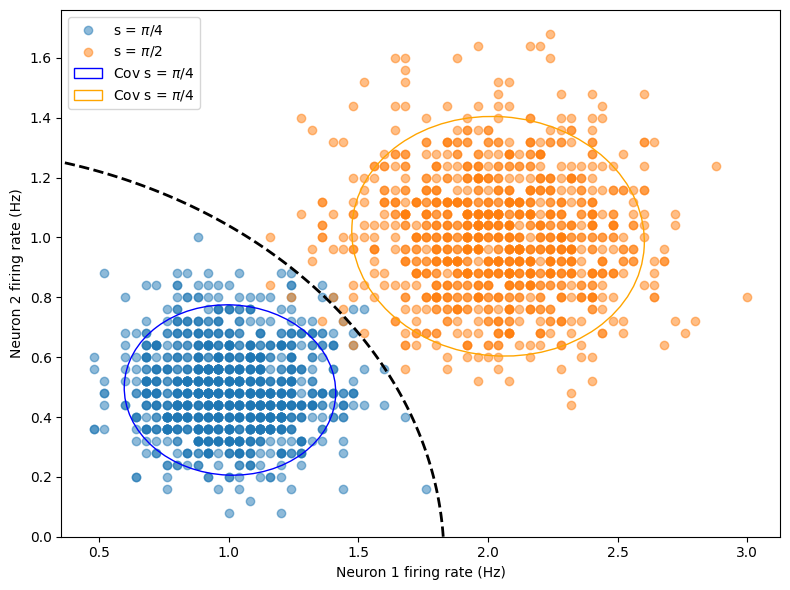

In [6]:
N_each = 1000
duration = 25.0

s1 = np.pi / 4
s2 = np.pi / 2
s = np.hstack([np.full(N_each, s1), np.full(N_each, s2)])
r1 = np.exp(np.sin(s - np.pi/4))
r2 = np.exp(np.sin(s - np.pi/2))
counts1 = np.random.poisson(r1 * duration)
counts2 = np.random.poisson(r2 * duration)
fr1 = counts1 / duration
fr2 = counts2 / duration

mask1 = (s == s1)
mask2 = (s == s2)
X1 = np.vstack([fr1[mask1], fr2[mask1]]).T
X2 = np.vstack([fr1[mask2], fr2[mask2]]).T

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label=r's = $\pi$/4')
ax.scatter(X2[:, 0], X2[:, 1], alpha=0.5, label=r's = $\pi$/2')

# Function to plot covariance ellipse
def plot_cov_ellipse(cov, mean, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

# Plot covariance ellipses for each cluster
mean1 = X1.mean(axis=0)
cov1 = np.cov(X1, rowvar=False, ddof=0)
plot_cov_ellipse(cov1, mean1, ax, edgecolor='blue', facecolor='none', label=r'Cov s = $\pi$/4')

mean2 = X2.mean(axis=0)
cov2 = np.cov(X2, rowvar=False, ddof=0)
plot_cov_ellipse(cov2, mean2, ax, edgecolor='orange', facecolor='none', label=r'Cov s = $\pi$/4')

# Decision boundary: log-likelihood ratio = 0. So we do contour plot and only plot level = 0
def log_gauss_pdf(X, mean, cov):
    inv_cov = np.linalg.inv(cov)
    diff = X - mean
    return -0.5 * np.sum(diff @ inv_cov * diff, axis=1) - 0.5 * np.log(np.linalg.det(cov))

# Contour grid
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

logp1 = log_gauss_pdf(grid, mean1, cov1)
logp2 = log_gauss_pdf(grid, mean2, cov2)
zz = (logp1 - logp2).reshape(xx.shape)

# Plot decision boundary contour where logp1 == logp2
ax.contour(xx, yy, zz, levels=[0], colors='k', linestyles='--', linewidths=2)

ax.set_xlabel('Neuron 1 firing rate (Hz)')
ax.set_ylabel('Neuron 2 firing rate (Hz)')
ax.legend()
plt.tight_layout()
plt.show()


f) Brainstorm at least three biologically plausible ways how noise covariances could appear in our measurements. Discuss whether they can be positive or negative. (1,5 points)

*Hint: You are allowed and encouraged to use the forum for an open exchange among students for this.*

1. **Shared upstream input**

    Fluctuations in a common presynaptic source drive both neurons on each trial. If that input is excitatory (or inhibitory) to both, their deviations rise or fall together (positive noise covariance). If it excites one and inhibits the other, their trial-by-trial responses move in opposite directions (negative noise covariance).

2. **Global brain state (arousal/attention)**

    Trial-to-trial changes in arousal or neuromodulators boost or suppress both cells simultaneously. When both are modulated in the same direction, we get positive noise covariance; if one’s gain goes up while the other’s goes down, we get negative noise covariance.

3. **Recurrent connections between the two neurons**

    Direct excitatory feedback means a random spike burst in neuron 1 will transiently increase neuron 2’s firing (positive covariance). Strong inhibitory coupling means neuron 1’s burst suppresses neuron 2 (negative covariance).

g) Choose one model that allows for positive and (!) negative noise correlations and implement it. Repeat the plot from e) with positive and negative noise correlations (two subplots). Discuss and compute (with MDE) whether the noise correlations support or obstruct decoding. (4 points)

In [7]:
def simulate_and_plot_noise_correlations(    
    s1,
    s2,
    sigma1,
    sigma2,
    rho_values,
    N_each=1000,
):

    mean_s1 = np.array([np.exp(np.sin(s1 - np.pi/4)), np.exp(np.sin(s1 - np.pi/2))])
    mean_s2 = np.array([np.exp(np.sin(s2 - np.pi/4)),np.exp(np.sin(s2 - np.pi/2))])

    fig, axes = plt.subplots(1, len(rho_values), figsize=(12, 5))
    results = []

    for ax, rho in zip(axes, rho_values):

        cov_noise = np.array([[sigma1**2,             rho * sigma1 * sigma2],
                              [rho * sigma1 * sigma2, sigma2**2            ]])
        X1 = np.random.multivariate_normal(mean_s1, cov_noise, size=N_each)
        X2 = np.random.multivariate_normal(mean_s2, cov_noise, size=N_each)

        # Plot
        ax.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label='s = π/4')
        ax.scatter(X2[:, 0], X2[:, 1], alpha=0.5, label='s = π/2')
        plot_cov_ellipse(cov_noise, mean_s1, ax, edgecolor='blue', facecolor='none')
        plot_cov_ellipse(cov_noise, mean_s2, ax, edgecolor='orange', facecolor='none')

        # Decision boundary: log-likelihood ratio = 0
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                             np.linspace(y_min, y_max, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        logp1 = log_gauss_pdf(grid, mean_s1, cov_noise)
        logp2 = log_gauss_pdf(grid, mean_s2, cov_noise)
        zz = (logp1 - logp2).reshape(xx.shape)
        ax.contour(xx, yy, zz, levels=[0], colors='k', linestyles='--')

        ax.set_title(f'Noise ρ = {rho}')
        ax.set_xlabel('Neuron 1 firing rate (Hz)')
        ax.set_ylabel('Neuron 2 firing rate (Hz)')
        ax.legend()

        # Compute MDE
        delta = mean_s1 - mean_s2
        dprime = np.sqrt(delta.T @ np.linalg.inv(cov_noise) @ delta)
        p_error = norm.cdf(-dprime / 2)
        results.append({'rho': rho, 'p_error': p_error})

    plt.tight_layout()
    return fig, results

ρ = 0.5: , P(error) ≈ 0.043
ρ = -0.5: , P(error) ≈ 0.005


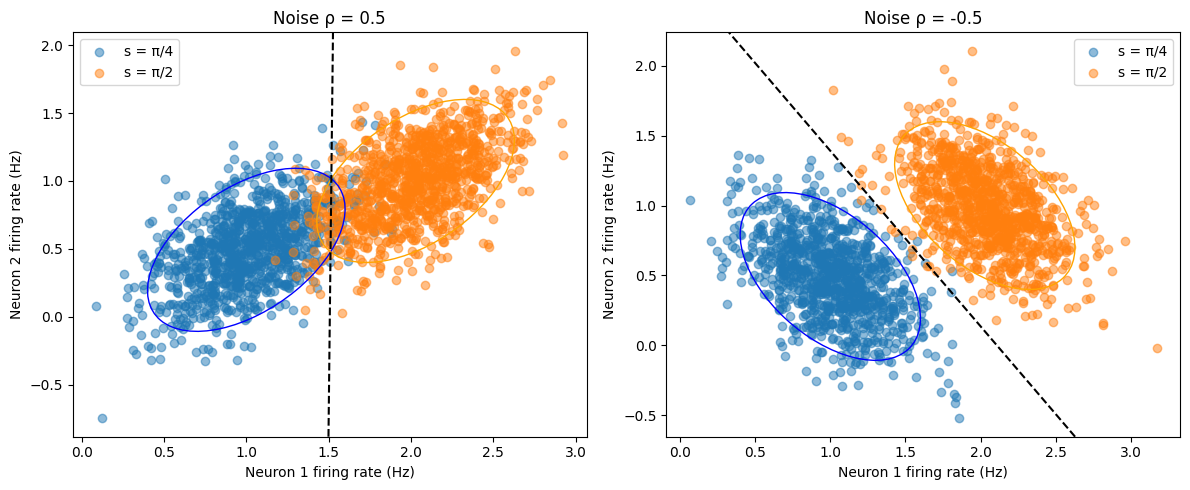

In [8]:
s1 = np.pi / 4
s2 = np.pi / 2
sigma1 = 0.3
sigma2 = 0.3
rho_values = [0.5, -0.5] # Correlation
fig, results = simulate_and_plot_noise_correlations(s1, s2, sigma1, sigma2, rho_values)
for res in results:
    print(f"ρ = {res['rho']}: , P(error) ≈ {res['p_error']:.3f}")

h) Repeat g) for a different set of stimuli that have the opposite (inversed sign) signal correlation. (1 point)

ρ = 0.5: , P(error) ≈ 0.011
ρ = -0.5: , P(error) ≈ 0.092


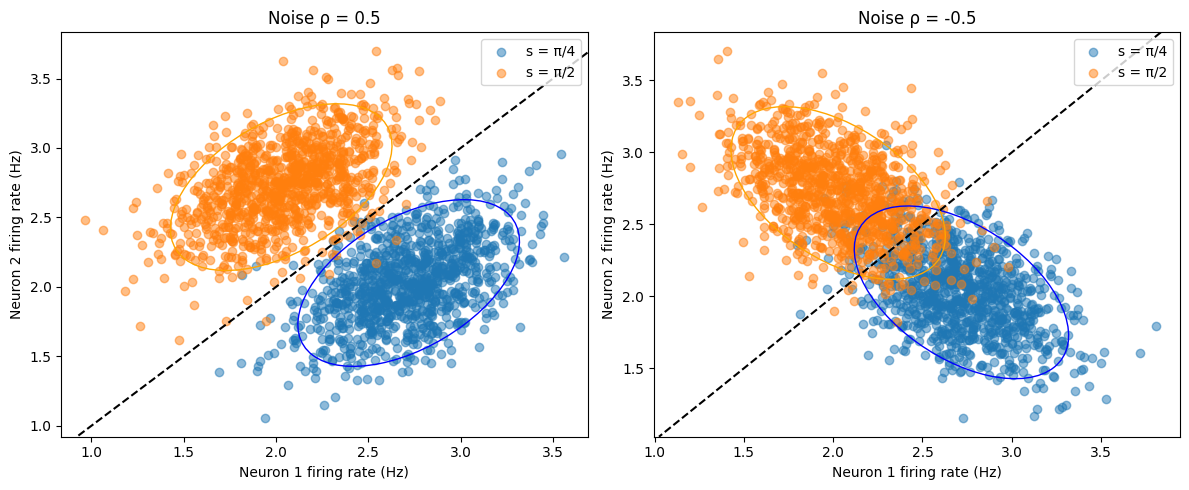

In [9]:
s1 = 3 * np.pi / 4
s2 = np.pi
sigma1 = 0.3
sigma2 = 0.3
rho_values = [0.5, -0.5] # Correlation
fig, results = simulate_and_plot_noise_correlations(s1, s2, sigma1, sigma2, rho_values)
for res in results:
    print(f"ρ = {res['rho']}: , P(error) ≈ {res['p_error']:.3f}")